# Cash-Flow Diagram: Digital-Banking Automation, Ported to Python

A minimal but real transaction-processing pipeline: parse a debit-card
transaction history (a generic CSV -- date, description, signed amount),
categorize each transaction by keyword, track a running balance, summarize
by month, and plot the result as a cash-flow diagram. Built and run here
against SYNTHETIC data (`generate_synthetic_transactions`) -- no real
account is touched -- but `parse_transactions_csv` is generic enough to read
an actual bank-exported CSV later; everything downstream works unchanged.
Engine: `dgs/cash_flow_diagram.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import cash_flow_diagram as cfd

print('Setup complete.')


Setup complete.


## 1. Synthetic Transactions and Keyword Categorization

`generate_synthetic_transactions` builds a realistic (but entirely made-up)
6 months of debit-card activity: biweekly paychecks, monthly rent/utilities,
and randomized groceries/dining/transport/subscriptions.
`categorize_transaction` keyword-matches each description into a spending
category, case-insensitively, falling back to `'other'` rather than raising
on an unrecognized description.


In [2]:
transactions = cfd.generate_synthetic_transactions(n_months=6, seed=42)
print(f'{len(transactions)} synthetic transactions generated')
print('\nfirst 5:')
for t in transactions[:5]:
    print(f"  {t['date']}  {t['description']:28s} {t['amount']:+9.2f}  -> {cfd.categorize_transaction(t['description'])}")


146 synthetic transactions generated

first 5:
  2026-01-01  PAYROLL DIRECT DEPOSIT        +2450.00  -> paycheck
  2026-01-02  RENT - APARTMENTS LLC         -1400.00  -> rent
  2026-01-02  TRADER JOE GROCERY              -31.09  -> groceries
  2026-01-02  CAFE RESTAURANT                 -19.32  -> dining
  2026-01-02  GAS STATION FUEL                -49.84  -> transport


## 2. Running Balance and Its Arithmetic Invariant

`compute_running_balance` walks the transactions in date order, and
verifies -- rather than assumes -- that
$$\text{ending balance}-\text{starting balance}=\sum(\text{transaction amounts}),$$
the one hard bookkeeping identity a running-balance computation must
satisfy (it raises `AssertionError` internally if this ever fails).


In [3]:
starting_balance = 1000.0
balance_history = cfd.compute_running_balance(transactions, starting_balance)

total_change = sum(t['amount'] for t in transactions)
ending_balance = balance_history[-1]['balance']
print(f'starting balance: {starting_balance:.2f}')
print(f'ending balance:   {ending_balance:.2f}')
print(f'total transaction sum: {total_change:.2f}')
print(f'invariant holds: {abs((ending_balance - starting_balance) - total_change) < 1e-9}')


starting balance: 1000.00
ending balance:   16922.54
total transaction sum: 15922.54
invariant holds: True


## 3. Balance Over Time


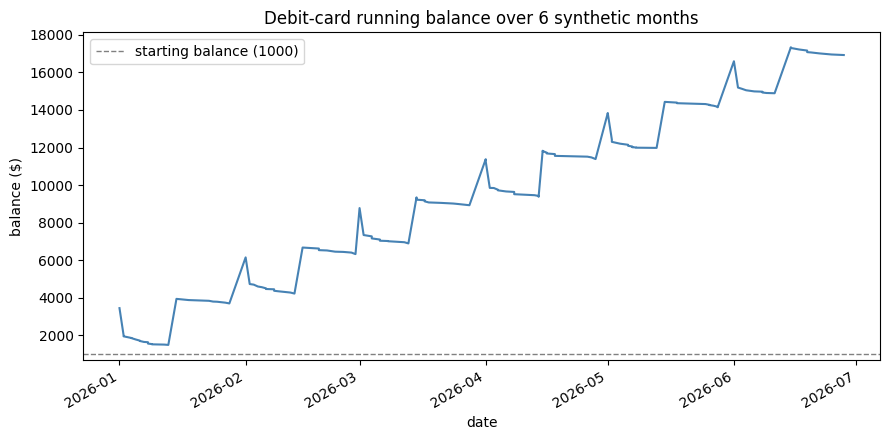

In [4]:
dates = [row['date'] for row in balance_history]
balances = [row['balance'] for row in balance_history]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(dates, balances, color='steelblue', lw=1.5)
ax.axhline(starting_balance, color='gray', ls='--', lw=1, label=f'starting balance ({starting_balance:.0f})')
ax.set_xlabel('date'); ax.set_ylabel('balance ($)')
ax.set_title('Debit-card running balance over 6 synthetic months')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('cash_flow_balance_over_time.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. The Cash-Flow Diagram: Monthly Inflow/Outflow by Category

`monthly_cash_flow_summary` groups transactions by (year, month) and totals
inflow, outflow, net, and a per-category breakdown -- the actual cash-flow
diagram: a stacked bar of category outflows against monthly paycheck
inflow.


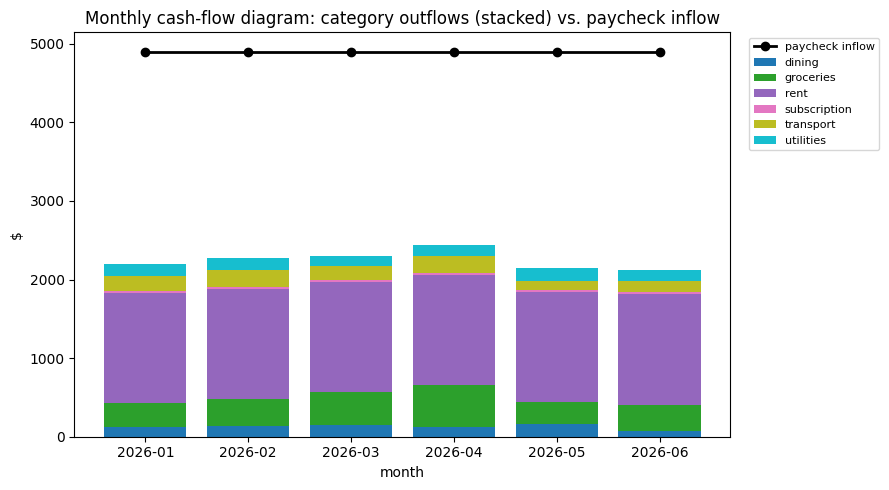

2026-01: inflow=4900.00  outflow=2199.48  net=+2700.52
2026-02: inflow=4900.00  outflow=2274.97  net=+2625.03
2026-03: inflow=4900.00  outflow=2297.59  net=+2602.41
2026-04: inflow=4900.00  outflow=2443.52  net=+2456.48
2026-05: inflow=4900.00  outflow=2143.34  net=+2756.66
2026-06: inflow=4900.00  outflow=2118.56  net=+2781.44


In [5]:
summary = cfd.monthly_cash_flow_summary(transactions)
months_sorted = sorted(summary.keys())
month_labels = [f'{y}-{m:02d}' for (y, m) in months_sorted]

categories = sorted({cat for (y, m) in months_sorted for cat in summary[(y, m)]['by_category']
                      if cat != 'paycheck'})
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(months_sorted))
for cat, color in zip(categories, colors):
    values = np.array([abs(summary[key]['by_category'].get(cat, 0.0)) for key in months_sorted])
    ax.bar(month_labels, values, bottom=bottom, label=cat, color=color)
    bottom += values

paycheck_values = [summary[key]['by_category'].get('paycheck', 0.0) for key in months_sorted]
ax.plot(month_labels, paycheck_values, 'o-', color='black', lw=2, label='paycheck inflow')

ax.set_xlabel('month'); ax.set_ylabel('$')
ax.set_title('Monthly cash-flow diagram: category outflows (stacked) vs. paycheck inflow')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('cash_flow_monthly_diagram.png', dpi=100, bbox_inches='tight')
plt.show()

for key in months_sorted:
    s = summary[key]
    print(f'{key[0]}-{key[1]:02d}: inflow={s["inflow"]:.2f}  outflow={s["outflow"]:.2f}  net={s["net"]:+.2f}')


## 5. The Generic CSV Path (for a Real Bank Export, Later)

`parse_transactions_csv` reads any CSV with a date, description, and signed
amount column (column names are parameters, since real bank exports vary)
-- demonstrated below on a small hand-written CSV, exercising the exact
code path a real bank export would use.


In [6]:
import csv, tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    csv_path = os.path.join(tmpdir, 'transactions.csv')
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['date', 'description', 'amount'])
        writer.writerow(['2026-01-01', 'PAYROLL DIRECT DEPOSIT', '2450.00'])
        writer.writerow(['2026-01-02', 'RENT - APARTMENTS LLC', '-1400.00'])
        writer.writerow(['2026-01-05', 'TRADER JOE GROCERY', '-62.30'])
    parsed = cfd.parse_transactions_csv(csv_path)

for t in parsed:
    print(f"{t['date']}  {t['description']:28s} {t['amount']:+9.2f}  -> {cfd.categorize_transaction(t['description'])}")


2026-01-01  PAYROLL DIRECT DEPOSIT        +2450.00  -> paycheck
2026-01-02  RENT - APARTMENTS LLC         -1400.00  -> rent
2026-01-05  TRADER JOE GROCERY              -62.30  -> groceries


## 6. Engineering Interpretation

- Section 2's invariant check is the one thing worth actually verifying in
  a "porting to Python" exercise like this: a running-balance loop LOOKS
  trivially correct, but an off-by-one in transaction order or a sign error
  in the amount convention breaks it silently -- checking the closed-form
  identity catches that class of bug immediately.
- `categorize_transaction`'s keyword approach is genuinely fragile (real
  bank descriptions are messier than this notebook's synthetic ones) --
  the `'other'` fallback exists specifically so an unrecognized transaction
  still shows up in the totals instead of vanishing or crashing the
  pipeline.
- Section 5 is the actual point of building this against synthetic data
  first: `parse_transactions_csv` is entirely decoupled from where the
  transactions come from, so swapping in a real bank-exported CSV later
  requires zero changes to categorization, balance tracking, or plotting.


## 7. Research Discussion

- `categorize_transaction`'s keyword lists are hand-written; could this be
  replaced with a small local classifier (matching this repo's `live_cas_ollama_win.py`
  pattern of using a local LLM) that categorizes from the RAW description
  text without maintained keyword lists, and how would its accuracy compare
  on ambiguous real-world descriptions ("SQ *COFFEE SHOP" style POS strings)?
- Section 4's stacked-bar diagram treats each month independently -- could
  `monthly_cash_flow_summary` be extended to compute a rolling N-month
  average per category, surfacing a slow trend (e.g. groceries drifting up)
  that a single month's bar can't show?
- The Rule-of-72/Taylor-correction work in `dgs/elementary_algebra.py` is a
  natural neighbor here: applying `doubling_time_taylor_correction` to an
  actual month-over-month savings growth rate computed from this notebook's
  balance history would connect the two notebooks concretely.


## 8. Possible Experiments

1. Export your own real transaction history as a CSV from your bank's
   website, point `parse_transactions_csv` at it (adjusting `date_col`/
   `desc_col`/`amount_col` to match its actual column names), and compare
   the resulting cash-flow diagram against this notebook's synthetic one.
2. Extend `CATEGORY_KEYWORDS` with your own recurring vendors and re-run
   the categorization to see how much of `'other'` shrinks.
3. Add a simple budget-alert function: given a category and a monthly cap,
   flag any month where `monthly_cash_flow_summary`'s category total
   exceeds it.


## 9. Future Improvements

- `generate_synthetic_transactions` uses fixed dollar amounts for
  rent/subscriptions; a more realistic generator could add small
  month-to-month variation (a rent increase, a subscription price change)
  to stress-test the categorizer against non-constant recurring charges.
- `parse_transactions_csv` assumes ISO date strings (`datetime.date.fromisoformat`);
  real bank exports often use locale-specific formats (`MM/DD/YYYY`) --
  a follow-up could add a `date_format` parameter using `datetime.strptime`.
